# Practicum 02

By submitting this notebook to Gradescope you are acknowledging that you are upholding the Duke honor code that this notebook is representative of the work of all that are on the submission and no one else.

This assessment can be done in teams of two. It represents your pair's work, and **only** your pair's work to show your all's understanding of the material. This document and your answers are for your pair's eyes only.

This exam is open book, open note, open Internet, open to large language models, and closed to people outside of your pair. This means you cannot communicate with someone outside of your pair about the practicum until grades are published, including asking someone through the Internet (like stackoverflow) to receive help.

You **may reuse** the results of prior questions (like variables or new columns) in later questions. If you do so, you need to clearly state it for the graders.

You **may not use** `for` or `while` loops if there are clear ways to do it using libraries and without such loops. In addition, the code must guarantee that the loop will iterate less than 25 times, including if we swap out the data for another data file with 10x more rows. Using such loops will immediately mark your solution as "Not Yet" because one large purpose of this exam is to assess your skills at taking advantage of the data science libraries.

If you think something is ambiguous or some assumption/key information is missing, decide on your own interpretation or any additional assumption and state them clearly.

The grading for this exam will be very lenient regarding the reasonableness of your use of the data since we do not expect you to have a great understanding of the data set. Moreover, the values in this data set do not necessarily reflect the real world.

# Practicum Update Diff Cell
If you are not updating your practicum for the Practicum Update, ignore this cell. If you are updating this notebook for the Practicum Update, fill out this template to make clear what you did and did not change.

### Question 1
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question, for example something like "We did not change the code and only changed the writeup to better answer questions 2 and 3.")

### Question 2
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question, for example something like "We cleaned up the code by removing the `==True` and did not change the writeup.")

### Question 3
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question)

### Question 4
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question)

# Overview Note

We recommend scanning through the entire exam before beginning so you have a sense of what each question is asking you to do.

Feel free to add columns to the dataframe and use them throughout the notebook. Just note in your writeup where the code for a particular new column is to make grading easier.

**Using LLMs**: For each question, there is a variable called `q#_llm_flag`. Set this to `True` if you used an LLM to help you with that question and `False` otherwise.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
# All imports you likely would need
## Models and modeling
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

## Data Munging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler

## Measurements
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Group Members
In the below cell provide the NetIds as strings of all the people working on this practicum. If you are working solo, write `student2`'s NetId as `'no1'`.

In [3]:
student1 = 'kdf32'
student2 = 'mdm144'


# Data Set: Video Games and Consoles

This data set contains data on video games and the consoles they can be played on. The `games.csv` table contains information about the games. A row in `games.csv` is a game regardless of the console it is in. The `game_consoles.csv` table contains information about the game dependent on what console it is for. A row in `game_consoles.csv` represents a (game, console) pair. A game can have multiple rows in `game_consoles.csv`.

You will need to merge the two data files (`games.csv` and `game_consoles.csv`) to create a third DataFrame. The merge key is `Title` in both files. 

You cannot assume that these will merge perfectly. There are some missing/extra games and (game, console) pairs in each data set.

## games.csv

| Variable  | Type | Description |
|-----------|------|-------------|
|`Title`| str | The full title of this game. |
|`Length.All PlayStyles.Average`| float64 | The mean time that players reported completing the game in any way, in hours. This is the average over all the other categories. |
|`Length.All PlayStyles.Leisure`| float64 | The slowest time that players reported completing the game in any way, in hours. This is the minimum over all the other categories. |
|`Length.All PlayStyles.Median`| float64 | The median time that players reported completing the game in any way, in hours. This is the median over all the other categories. |
|`Length.All PlayStyles.Polled`| int64 | The number of players that reported completing the game in any way. This is the count over all the other categories. |
|`Length.All PlayStyles.Rushed`| float64 | The fastest time that players reported completing the game in any way, in hours. This is the maximum over all the other categories. |
|`Length.Completionists.Average`| float64 | The mean time that players reported completing everything in the game, in hours. |
|`Length.Completionists.Leisure`| float64 | The slowest time that players reported completing everything in the game, in hours. |
|`Length.Completionists.Median`| float64 | The median time that players reported completing everything in the game, in hours. |
|`Length.Completionists.Polled`| int64 | The number of players that reported completing everything in the game. |
|`Length.Completionists.Rushed`| float64 | The fastest time that players reported completing everything in the game, in hours. |
|`Length.Main + Extras.Average`| float64 | The mean time that players reported completing the main game and major extra parts of the game, in hours. |
|`Length.Main + Extras.Leisure`| float64 | The slowest time that players reported completing the main game and major extra parts of the game, in hours. |
|`Length.Main + Extras.Median`| float64 | The median time that players reported completing the main game and major extra parts of the game, in hours. |
|`Length.Main + Extras.Polled`| int64 | The number of players that reported completing the main game and major extra parts of the game. |
|`Length.Main + Extras.Rushed`| float64 | The fastest time that players reported completing the main game and major extra parts of the game, in hours. |
|`Length.Main Story.Average`| float64 | The mean time that players reported completing the main game storyline, in hours. |
|`Length.Main Story.Leisure`| float64 | The slowest time that players reported completing the main game storyline, in hours. |
|`Length.Main Story.Median`| float64 | The median time that players reported completing the main game storyline, in hours. |
|`Length.Main Story.Polled`| int64 | The number of players that reported completing the main game storyline. |
|`Length.Main Story.Rushed`| float64 | The fastest time that players reported completing the main game storyline, in hours. |

## game_consoles.csv

| Variable  | Type | Description |
|-----------|------|-------------|
|`Title`| str | The full title of this game. |
|`Release.Console`| str | The name of the console that this particular game was released for. Note that the dataset contains multiple copies of the same game, released for different consoles. |
|`Publisher`| str | If there is only one publisher for the video game, this is it's name |
|`Publisher Location`| str | Main location of the publisher |
|`Publisher Established`| float64 | What year the publisher was formed |
|`Notable games published`| str | Games the publisher is well known for |
|`Publisher Notes`| str | Other notes about the publisher |
|`Features.Max Players`| int64 | The maximum number of players that can play this game. |
|`Metadata.Genres`| str | The list of genres that this game belongs to. |
|`Metadata.Publishers`| str | The list of all publishers who created this game |
|`Metrics.Review Score`| int64 | A typical review score for this game, out of 100. |
|`Metrics.Sales`| float64 | The total sales made on this game, measured in millions of dollars. |
|`Metrics.Used Price`| float64 | A typical "used" price for this game (i.e. previously returned and sold), measured in dollars. It is unclear where this number originally came from. |
|`Release.Rating`| str | The ESRB rating for this game, either E (for Everyone), T (for Teen), or M (for Mature). |
|`Release.Year`| int64 | The year that this game was released. |

In [4]:
# import policy data
games = pd.read_csv('games.csv')
print(games.shape)
print('Columns:', games.columns)
games.describe(include='all')

(901, 21)
Columns: Index(['Title', 'Length.All PlayStyles.Average',
       'Length.All PlayStyles.Leisure', 'Length.All PlayStyles.Median',
       'Length.All PlayStyles.Polled', 'Length.All PlayStyles.Rushed',
       'Length.Completionists.Average', 'Length.Completionists.Leisure',
       'Length.Completionists.Median', 'Length.Completionists.Polled',
       'Length.Completionists.Rushed', 'Length.Main + Extras.Average',
       'Length.Main + Extras.Leisure', 'Length.Main + Extras.Median',
       'Length.Main + Extras.Polled', 'Length.Main + Extras.Rushed',
       'Length.Main Story.Average', 'Length.Main Story.Leisure',
       'Length.Main Story.Median', 'Length.Main Story.Polled',
       'Length.Main Story.Rushed'],
      dtype='object')


,Title,Length.All PlayStyles.Average,Length.All PlayStyles.Leisure,Length.All PlayStyles.Median,Length.All PlayStyles.Polled,Length.All PlayStyles.Rushed,Length.Completionists.Average,Length.Completionists.Leisure,Length.Completionists.Median,Length.Completionists.Polled,...,Length.Main + Extras.Average,Length.Main + Extras.Leisure,Length.Main + Extras.Median,Length.Main + Extras.Polled,Length.Main + Extras.Rushed,Length.Main Story.Average,Length.Main Story.Leisure,Length.Main Story.Median,Length.Main Story.Polled,Length.Main Story.Rushed
count,901,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,...,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000
unique,901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Super Mario 64 DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,14.064595,26.563078,11.716371,41.244173,9.796578,20.880318,26.963134,19.738957,5.317425,...,12.393396,18.109119,11.817037,13.402886,9.945413,8.826045,11.408546,8.618794,22.560488,7.290622
std,NaN,20.558099,52.694270,14.376971,149.561820,11.973502,50.594329,65.840603,47.524666,19.734437,...,21.220518,39.871647,20.591422,57.357909,17.073326,10.560405,14.908565,10.346059,81.232068,8.698144
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,3.000000,3.500000,2.500000,1.000000,2.266667,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,8.750000,11.750000,8.000000,5.000000,6.683333,5.000000,5.216667,4.750000,1.000000,...,6.600000,7.150000,6.333333,1.000000,5.666667,6.283333,7.816667,6.000000,3.000000,5.250000
75%,NaN,17.266667,28.300000,15.000000,22.000000,12.383333,22.516667,28.350000,21.766667,3.000000,...,16.083333,21.033333,15.000000,6.000000,13.183333,11.683333,15.000000,11.033333,13.000000,9.933333


In [5]:
# import game consoles data
game_consoles = pd.read_csv('game_consoles.csv')
print(game_consoles.shape)
print('Columns:', game_consoles.columns)
game_consoles.describe(include='all')

(1205, 15)
Columns: Index(['Title', 'Release.Console', 'Publisher', 'Publisher Location',
       'Publisher Established', 'Notable games published', 'Publisher Notes',
       'Features.Max Players', 'Metadata.Genres', 'Metadata.Publishers',
       'Metrics.Review Score', 'Metrics.Sales', 'Metrics.Used Price',
       'Release.Rating', 'Release.Year'],
      dtype='object')


,Title,Release.Console,Publisher,Publisher Location,Publisher Established,Notable games published,Publisher Notes,Features.Max Players,Metadata.Genres,Metadata.Publishers,Metrics.Review Score,Metrics.Sales,Metrics.Used Price,Release.Rating,Release.Year
count,1205,1205,923,923,923.000000,913,845,1205.000000,1205,942,1205.000000,1205.000000,1205.000000,1205,1205.000000
unique,901,5,18,15,NaN,17,14,NaN,48,31,NaN,NaN,NaN,3,NaN
top,Harry Potter and the Order of the Phoenix,Nintendo DS,EA,"Tokyo, Japan",NaN,*Battlefield* series\n*Medal of Honor* series\...,video game developer,NaN,Action,EA,NaN,NaN,NaN,E,NaN
freq,5,315,165,185,NaN,165,211,NaN,476,165,NaN,NaN,NaN,486,NaN
mean,NaN,NaN,NaN,NaN,1972.537378,NaN,NaN,1.658921,NaN,NaN,68.837344,0.504066,17.401452,NaN,2006.821577
std,NaN,NaN,NaN,NaN,28.712530,NaN,NaN,1.205199,NaN,NaN,12.961101,1.072386,5.028854,NaN,1.052066
min,NaN,NaN,NaN,NaN,1889.000000,NaN,NaN,1.000000,NaN,NaN,19.000000,0.010000,4.950000,NaN,2004.000000
25%,NaN,NaN,NaN,NaN,1969.000000,NaN,NaN,1.000000,NaN,NaN,60.000000,0.090000,14.950000,NaN,2006.000000
50%,NaN,NaN,NaN,NaN,1982.000000,NaN,NaN,1.000000,NaN,NaN,70.000000,0.210000,17.950000,NaN,2007.000000
75%,NaN,NaN,NaN,NaN,1988.000000,NaN,NaN,2.000000,NaN,NaN,79.000000,0.460000,17.950000,NaN,2008.000000


In [6]:
# Feel free to use this cell and add more to explore the data

# Question 1 (29 points: 5 autograded, 24 manually graded)
 
Do the following:
1. Merge the two DataFrames into a single DataFrame so that you keep all of the data about (game, console) pairs. That means you will lose game data for (game, console) pairs not in the `game_consoles` table, and you keep all data about (game, console) pairs regardless of whether there is game data available for them. Put the merged dataframe in a variable called `df_merged`
1. Put the number of rows and columns of `df_merged` into `rows` and  `columns` respectively.
1. Choose a column from `df_merged`:
    1. Put in `non_nan_count`, the number of values in this column that are not a NaN.
    1. Calculate a single descriptive statistic, and place it in `statistic`. This could be from a numerical or string column; for example, it could be the count of something in a string column.

**See the written portion of this question to see what you must explain.**

## Answer 1: Code

In [7]:
q1_llm_flag = False

df_merged = pd.merge(games, game_consoles, on='Title', how='right')
rows = df_merged.shape[0]
columns = df_merged.shape[1]

game_genres = df_merged["Metadata.Genres"]
action_games = game_genres[game_genres.str.contains("Action")]

non_nan_count = game_genres.count() # count excludes NaN by default
statistic = action_games.count()

# Leave these here to help with grading.
print('Number of rows:', rows)
print('Number of columns:', columns)
print('Number of values that are not NaN in the column of interest:', non_nan_count)
print('Descriptive statistic of a column:', statistic)

# For Visualization
df_merged.describe(include='all')

Number of rows: 1205
Number of columns: 35
Number of values that are not NaN in the column of interest: 1205
Descriptive statistic of a column: 727


,Title,Length.All PlayStyles.Average,Length.All PlayStyles.Leisure,Length.All PlayStyles.Median,Length.All PlayStyles.Polled,Length.All PlayStyles.Rushed,Length.Completionists.Average,Length.Completionists.Leisure,Length.Completionists.Median,Length.Completionists.Polled,...,Notable games published,Publisher Notes,Features.Max Players,Metadata.Genres,Metadata.Publishers,Metrics.Review Score,Metrics.Sales,Metrics.Used Price,Release.Rating,Release.Year
count,1205,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000,...,913,845,1205.000000,1205,942,1205.000000,1205.000000,1205.000000,1205,1205.000000
unique,901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17,14,NaN,48,31,NaN,NaN,NaN,3,NaN
top,Harry Potter and the Order of the Phoenix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,*Battlefield* series\n*Medal of Honor* series\...,video game developer,NaN,Action,EA,NaN,NaN,NaN,E,NaN
freq,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,165,211,NaN,476,165,NaN,NaN,NaN,486,NaN
mean,NaN,13.758619,26.477364,11.312050,44.949791,9.468480,19.933724,25.965955,18.921088,5.722176,...,NaN,NaN,1.658921,NaN,NaN,68.837344,0.504066,17.401452,NaN,2006.821577
std,NaN,19.484172,51.889223,13.541916,155.864964,11.217192,46.892934,61.863035,44.286617,19.833642,...,NaN,NaN,1.205199,NaN,NaN,12.961101,1.072386,5.028854,NaN,1.052066
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,1.000000,NaN,NaN,19.000000,0.010000,4.950000,NaN,2004.000000
25%,NaN,3.750000,4.383333,3.175000,1.000000,2.708333,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,1.000000,NaN,NaN,60.000000,0.090000,14.950000,NaN,2006.000000
50%,NaN,8.966667,12.133333,8.000000,6.000000,6.750000,6.000000,6.483333,6.000000,1.000000,...,NaN,NaN,1.000000,NaN,NaN,70.000000,0.210000,17.950000,NaN,2007.000000
75%,NaN,16.033333,27.841667,14.000000,25.000000,11.491667,21.733333,27.191667,20.350000,3.000000,...,NaN,NaN,2.000000,NaN,NaN,79.000000,0.460000,17.950000,NaN,2008.000000


<!-- BEGIN QUESTION -->

## Answer 1: Written portion

Discuss the following:
1. What does a row in the merged dataframe represent in relation to games and (game, console) information? Make sure to note what information is duplicated in the merged table from the left/right table and where NaNs could appear due to how the tables were merged.
1. What is your descriptive statistic? What does it tell you about the data? Take into account the number of non-NaN values versus the number of rows
1. What does the code you wrote do? You do not need to describe any code that you have already described in the other written answers.

1. Each row in df_merged represents a unique (game, console) pair. Given that pd.merge() was called with the argument how="right", where "game_consoles" is on the right, we keep each (game, console) pair and potentially duplicate rows from "games" to fill information about each respective game. Therefore, information in a single row in "games" could be duplicated multiple times to be appended to rows in "game_consoles" with the same game but varying consoles. NaNs could appear for games that do not have an entry in "games" but do have an entry in "game_consoles". In this case, we force the (game, console) pair to be kept but cannot fill relevant game information because that information does not exist in "games". 
2. My descriptive statistic is the total number of (game, console) pairs that fall in the action category, which is 727. In other words, 727 of the (game, console) pairs in the list are action games. There are 1205 non-NaN values, which is the same as the number of original rows. This is unsurprising, as this column comes from "game_consoles" and we kept all rows from "game_consoles" during the merge step.
3. To merge the two datasets, we call pd.merge() on our two target dataframes and specify that "Title" should be the key with which to connect the two dataframes, and all entries from "game_consoles" on the right should be kept. To find rows and columns, we find its shape, which is returned as a tuple of (rows, columns). "game_genres" is a pandas series that contains all elements from the "Metadata.Genres" column of df_merged. "action_games" filters "game_genres" for all that contain the string "Action" to produce our desired entries. "non_nan_count" is found by filtering "game_genres" for entries that are not NaN and counting the number of rows. "statistic" is also found by filtering "action_games" for entries that are not NaN and counting the number of rows.

<!-- END QUESTION -->

# Question 2 (30 points: 5 autograded, 25 manually graded)

Do the following with one of the dataframes (`df_merged`, `games`, or `game_consoles`) to do a bootstrap:
1. Select two meaningful non-overlapping sets of data where each set must have at least 20 rows.
1. Create a 95% confidence interval for each set of data using bootstrapping with `10000` bootstrap resamples for a feature and with a statistic of your choice.
1. Put the number of rows in the first and second data sets in `n1` and `n2`, respectively.
1. Put the confidence intervals from the first and second sets of data in `interval1` and `interval2`, respectively. The intervals should be tuples, with the lower value at index 0 and the higher value at index 1.

Note: You may make as many new column(s) as you like.

**See the written portion of this question to see what you must explain.**

## Answer 2: Code

In [8]:
q2_llm_flag = False

np.random.seed(2026)

wii_games = df_merged[df_merged["Release.Console"] == "Nintendo Wii"]
wii_games = wii_games["Length.All PlayStyles.Average"].dropna().to_numpy()

ds_games = df_merged[df_merged["Release.Console"] == "Nintendo DS"]
ds_games = ds_games["Length.All PlayStyles.Average"].dropna().to_numpy()

wii_bootstrap_indices = np.random.randint(0, len(wii_games), size=(10000, len(wii_games)))
wii_bootstrap_mean = np.mean(wii_games[wii_bootstrap_indices], axis=1)

ds_bootstrap_indices = np.random.randint(0, len(ds_games), size=(10000, len(ds_games)))
ds_bootstrap_mean = np.mean(ds_games[ds_bootstrap_indices], axis=1)

n1 = len(wii_games)
interval1 = (np.percentile(wii_bootstrap_mean, 2.5), np.percentile(wii_bootstrap_mean, 97.5))

n2 = len(ds_games)
interval2 = (np.percentile(ds_bootstrap_mean, 2.5), np.percentile(ds_bootstrap_mean, 97.5))

# Leave these here to help with grading.
print(f"N1: {n1}, N2: {n2}")
print('Confidence interval 1:', interval1)
print('Confidence interval 2:', interval2)

N1: 183, N2: 314
Confidence interval 1: (np.float64(9.182732240437158), np.float64(14.50465619307832))
Confidence interval 2: (np.float64(12.379404193205946), np.float64(16.522806528662414))


<!-- BEGIN QUESTION -->

## Answer 2: Written portion

Discuss the following:
1. Why did you pick the table that you used?
1. What does the code you wrote do?
1. Why did you select the data you used in terms of the specific data column(s)?
1. State and clearly label a null (H0) and an alternative (HA) hypothesis that you can test using these confidence intervals.
1. Do the confidence intervals overlap? What does that mean? Take into account the size of the subsets of data you bootstrapped on.

1. I chose to use the df_merged dataframe because the columns I was interested in (Release.Console and Length.All PlayStyles.Average) were both present in this dataframe. One comes from "games" while the other comes from "game_consoles," so neither of those dataframes contained both columns.
2. My code repeats the following steps for both Nintendo Wii games and Nintendo DS games:
First, a seed is set for np.random in order for reproducibility. Then, I isolate rows in which the (game, console) pair matches the appropriate console and isolate the column containing its length across all playstyles, before removing NaNs and converting to its underlying numpy array. From here, numpy generates a 2D array of size 10000 x n, where each value is a random index to a row in my data. Each index is then swapped for the actual game length value in the row corresponding to that index, and a mean is taken across each row. In this way, I randomly sample 10000 distributions from my original data, each of size n, and take the mean of each to produce a bootstrapped distribution. From each, the 95% CI is calculated and reported.
3. I was interested in looking at game length differences between the Nintendo Wii and Nintendo DS, so I filtered for each respective game console in the "Release.Console" column. I chose "Length.All PlayStyles.Average" as a measure of game length, as the data reports it as being a measure of "the mean time players reported beating the game in any way" for each game.
4. In both of these statements, the "length" of a game is taken to mean "the mean time players reported beating the game in any way" in this dataset.

$H_0$: The true mean length of all Nintendo Wii games is equal to the true mean length of all Nintendo DS games ($μ_\text{Wii} = μ_\text{DS}$).

$H_A$: The true mean length of all Nintendo Wii games is significantly different from the true mean length of all Nintendo DS games ($μ_\text{Wii} \neq μ_\text{DS}$)

5. The confidence intervals do overlap ((9.183, 14.505) and (12.379, 16.523)). This means that we do not find statistically significant evidence to reject the $H_0$. For the two subsets of data analyzed, n = 183 and n = 314. Both are reasonably large, providing us reasonably narrow and precise confidence intervals that are likely reflective of the trends we look to analyze.

<!-- END QUESTION -->

# Question 3 (20 points: 3 autograded, 17 manually graded)

In this question you will train 2 **linear regression** models. Do the following:
1. Pick one of the dataframes: `df_merged`, `games`, or `game_consoles`.
1. `col_target` - Pick a numerical variable that will be the column you will train your models to predict. It cannot be a binary variable. Put the name of this numerical column in `col_target` of type `str`.
1. Encode a column
    1. Pick a column of type string that needs to be encoded using [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder "‌") or [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder "‌").
    1. Filter the entire data set down so there are at most 10 unique categories for the encoder.
    1. Put the name of the column you are encoding in `col_encode`.
1. In `all_cols3` of type `list` put all of the columns that you plan to use for your models, which should be the following for a total of 4-5 columns.
    1. `col_target`
    1. `col_encode`
    1. 2-3 other columns - You may create and use new columns, such as extracting information from the date columns.
1. Build 2 models as follows (you do not have to split test and train if you do not want to):
    1. Model 1 - Uses all of the data.
    1. Model 2 - Uses all of the data except a column of your choice.
1. Calculate each model's MSE and $r^2$ and report them in `mse_1`, `r2_1`, `mse_2`, and `r2_2` respectively.

Note: Negative/"bad" results are okay. What matters is your discussion of the results.

**See the written portion of this question to see what you must explain.**

## Answer 3: Code

In [9]:
q3_llm_flag = False

col_target = "Metrics.Review Score"
col_encode = "Release.Console" # Doesn't need filtering as there are only 5 nominal categories
col_used_price = "Metrics.Used Price"
col_rel_year = "Release.Year"
col_story_avg = "Length.Main Story.Average"

all_cols3 = [col_target, col_encode, col_used_price, col_rel_year, col_story_avg]

regression_df = df_merged[all_cols3].dropna()

encoder = OneHotEncoder(sparse_output=False, drop="first")
encoded_data = encoder.fit_transform(regression_df[[col_encode]])
encoded_cols = encoder.get_feature_names_out([col_encode])
encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=regression_df.index)

target_scores = regression_df[col_target]
features_other = [col_used_price, col_rel_year, col_story_avg]
features_full = pd.concat([encoded_df, regression_df[features_other]], axis=1)

# Build Model 1 here

model1 = LinearRegression()
model1.fit(features_full, target_scores)
target_scores_pred = model1.predict(features_full)

mse_1 = mean_squared_error(target_scores, target_scores_pred)
r2_1 = r2_score(target_scores, target_scores_pred)

# Build Model 2 here

features_no_price = features_full.drop(columns=[col_used_price])

model2 = LinearRegression()
model2.fit(features_no_price, target_scores)
target_scores_pred2 = model2.predict(features_no_price)

mse_2 = mean_squared_error(target_scores, target_scores_pred2)
r2_2 = r2_score(target_scores, target_scores_pred2)

# Leave these here to help with grading.
print('Column encoding:', col_encode)
print('Columns:', all_cols3)
print('Enough columns?', 4 <= len(all_cols3) <= 5)
print('Number of unique values in', col_encode, 'column unfiltered merged table:', df_merged[col_encode].nunique())
print('Model 1 - mse:', mse_1,'r2:', r2_1)
print('Model 2 - mse:', mse_2,'r2:', r2_2)

Column encoding: Release.Console
Columns: ['Metrics.Review Score', 'Release.Console', 'Metrics.Used Price', 'Release.Year', 'Length.Main Story.Average']
Enough columns? True
Number of unique values in Release.Console column unfiltered merged table: 5
Model 1 - mse: 148.63903356139946 r2: 0.11534043801357852
Model 2 - mse: 150.81760751348682 r2: 0.10237415162143448


<!-- BEGIN QUESTION -->

## Answer 3: Written portion

Discuss the following:
1. Why did you use your chosen table?
1. Which columns you chose for the target and data and why you chose those columns.
1. Why did you choose the encoder you used? If you filtered, explain why. If you did not filter at all, just state as much.
    1. Also elaborate on:
        1. If you used `OrdinalEncoder`, explain why you ordered the categories as you did.
        1. If you used `OneHotEncoder`, either explain (1) what order you would have used and why or (2) why an order does not make sense.
1. What does the code you wrote do? Make sure to explain any parameters or functions you used that were not used by the class video or worked examples (to demonstrate you understand this code). Also explain why you chose to deviate from any default behavior. You do not need to describe any code that you have already described in the other written answers.
1. Compare and contrast your models.
    1. Is there a clear ranking between the models? Why or why not? If there is a ranking, what is it?
    1. What do the models' performance differences tell you about the held-out column?

Note: Negative/"bad" results are okay. What matters is your discussion of the results.

1. The `df_merged` table was chosen because it provides the most comprehensive view of the data. By combining the `games` dataset with the `game_consoles` dataset, we can analyze the intersection between a game’s internal content and its extrinsic market performance. This allows the model to see if physical factors, like which console a game was released on, correlate with its critical reception.
2. The column `Metrics.Review Score` was chosen as the target data to predict the game's quality. A game's overall review score as the target potentially offers the most insight in how various features affect the game's reception. We chose `Release.Console` to see if certain platforms have correlate with a measurable "premium" associated with that specific brand associates with. We chose `Metrics.Used Price` to see if market value reflects quality of the game. We chose `Release.Year` to account for the evolution of games and their quality, and `Length.Main Story.Average` to see if longer games are perceived as higher value by critics, or if shorter games are preferred to maintain player attention and enjoyment.
3. `OneHotEncoder` was used on the `Release.Console` column without filtering, as there are only 5 unique categories. Because there is no larger order that makes one console better than another, `OneHotEncoder` was used. Consoles utilize different hardware and allow for unique, platform-specific releases which, if ordered, would force the model to make arbitrary assumptions. This allows the model to treat each console as an independent demographic without assuming a numerical distance between them. However, if the data only contained a single console line, such as the PlayStation to to PlayStation 5, a hierarchy could theoretically be justified.
4. The code prepares the data for linear regression by converting categorical strings into a format the model can process. We dropped `Nan` values in order to ensure the model doesn't encounter values that would cause the regression function to fail. `sparse_output=False` was used with `OneHotEncoder` so the result is a standard numpy array that is easy to convert into a DataFrame. We chose `drop='first'` to account for multicollinearity. `LinearRegression().fit()` was used, utilzing the Ordinary Least Squares method to find the weights for each feature that minimize the sum of squared residuals. We finally account for MSE and r2 values to quantify performance.
5. Model 1 (all features) is slightly better than Model 2, having a higher r2 (Model1≈0.115 vs. Model2≈0.102) and a lower error rate (Model1≈148.6 vs. Model2≈150.8). The very small change in r2 after dropping Used Price tells us that Used Price is a rather weak factor in predicting review scores. The low overall r2 suggests that while console and length help, most of what makes a game "good" to a critic comes from qualitative things like fun or art style, which aren't in this dataset.

<!-- END QUESTION -->

# Question 4 (20 points: 3 autograded, 17 manually graded)

In this question, you will train 2 classifier models. We recommend you write the code in 3 separate cells, as marked below, to make organizing and grading your code easier. Do the following:

1. Pick one of the dataframes: `df_merged`, `games`, or `game_consoles`.
1. `col_cat` - The column that you will classify or the column you used to create the column you classified on. Put the name of the column you are classifying in `col_cat`.
1. Filter the data so that it has 2-7 categories and at least 300 rows (you may use no filter if the column has 7 or fewer categories).
1. In `all_cols4` of type `list`, put all of the columns you plan to use for your models. You should have a total of 4-5 columns with the following criteria:
   1. `col_cat`
   1. 3-4 other columns, one of which can be `col_encode` from the linear regression question.
2. Build 2 models using the same kind of classifier (logistic regression, Naive Bayes, or K nearest neighbors) as follows:
   1. Model 1: Uses all of the data.
   1. Model 2: Holds out one column of data.
4. Split the data such that 25% is the test set.
5. Train the models on the training set.
6. With the test set:
   1. Plot or show a confusion matrix for all the models.
   1. Calculate model 1's accuracy and put it in `accuracy_model1`
   1. Calculate model 2's accuracy and put it in `accuracy_model2`
   3. If you used cross-fold validation to find a hyperparameter, print it for each model.

*Use only `ConfusionMatrixDisplay`. If your code breaks when you use this, you have an older version of `sklearn` and must update. No matter which one you use, if your text overlaps, use the `xticks_rotation='vertical'` option to rotate the text.*

Note: Negative/"bad" results are okay. What matters is your discussion of the results.

The written part of this question is separated into **two** subparts for easier answering and grading. **See those respective parts to see what you must explain.**

## Answer 4: Code

In [10]:
# Prepare your data
q4_llm_flag = False

col_cat = "Release.Rating" # 3 categories no filter necessary
col_comp_avg = "Length.Completionists.Average"
col_sales = "Metrics.Sales"
col_max_player = "Features.Max Players"
all_cols4 = [col_cat, col_comp_avg, col_sales, col_max_player]


# Leave these here to help with grading.
print('Columns:', all_cols4)
print('Enough columns?', 4 <= len(all_cols4) <= 5)
print('Number of unique values in', col_cat, 'column unfiltered table:', df_merged[col_cat].nunique())

Columns: ['Release.Rating', 'Length.Completionists.Average', 'Metrics.Sales', 'Features.Max Players']
Enough columns? True
Number of unique values in Release.Rating column unfiltered table: 3


In [11]:
# Build models
classification_df = df_merged[all_cols4].dropna()

features_full = classification_df.drop(columns=[col_cat])
target_labels = classification_df[col_cat]

# Split (25% test)
X_train, X_test, y_train, y_test = train_test_split(
    features_full, target_labels, test_size=0.25, random_state=42
)

# Model 1
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy_model1 = accuracy_score(y_test, y_pred1)

# Model 2

X_train_2 = X_train.drop(columns=[col_max_player])
X_test_2 = X_test.drop(columns=[col_max_player])

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_2, y_train)

y_pred2 = model2.predict(X_test_2)

accuracy_model2 = accuracy_score(y_test, y_pred2)

# To plot the confusion matrix, call the function in the new cell below.

# Leave these here to help with grading.
print('Model 1 Accuracy:', accuracy_model1)
print('Model 2 Accuracy:', accuracy_model2)

Model 1 Accuracy: 0.38127090301003347
Model 2 Accuracy: 0.3745819397993311


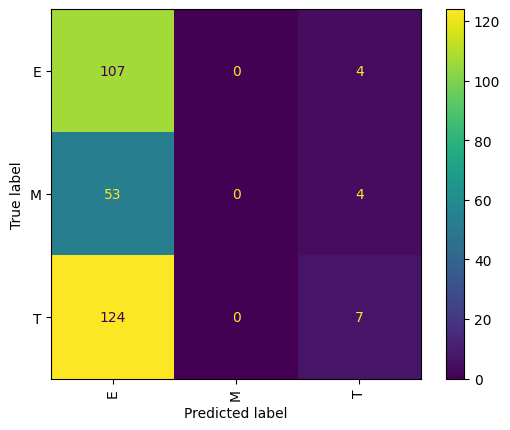

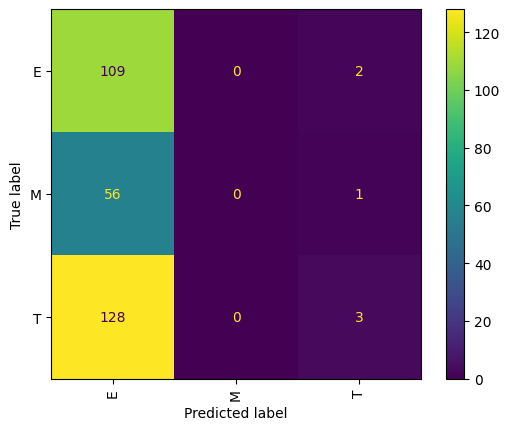

In [12]:
# Put your confusion matrix calls here.

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred1, xticks_rotation='vertical'
)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred2, xticks_rotation='vertical'
)

<!-- BEGIN QUESTION -->

## Answer 4.1: Data and Model
In the cell below, discuss the following
1. Why did you use this table for your model?
1. Which columns did you choose for the data and target? Why did you choose those columns? If you did anything to the columns, explain and state why.
1. How did you filter, and why did you choose to keep the categories that you did? If you did not filter at all, just state as much.
1. State which model type you used and why. Why are the other models equally or less viable of an option? If you used cross-fold validation to find a hyperparameter, mention it here or make sure to print it in your code for each model.
1. Explain any code not already explained by the prior written answers. Make sure to explain any parameters or functions you used that were not used by the class videos or worked examples and why you chose to use them (to demonstrate you understand this code). Also explain why you chose to deviate from any default behavior.

1. As mentioned in Q3, `df_merged` was once again used because it provides the most diverse set of features relating to both the internal and external factors of games. These types of models for game ratings `Release.Rating` benefit from looking at both content-based metrics like `Length.Completionists.Average` and market-based metrics like `sales`. This table is the only one that allows us to see if there is a relationship between how long a game takes to finish and the age group it is rated for.
2. `Release.Rating` was chosen as the target as it represents a classification of video games that other metrics may or may not be able to reliably map back to. For example, games that are rated E for everyone may or may not, on average, have higher sales, or a different style of gameplay. `Length.Completionists.Average` was chosen to test the correlation between content volume and mature themes. M-rated games often feature complex, narrative-heavy RPG or open-world elements meant for older audiences with higher attention spans, whereas E-rated games are often bite-sized. `Metric.Sales` was chosen to investigate whether or not market reach is a limiting factor. As aformentioned, Games rated E have larger theoretical outreach, everyone, while M-rated games are constricted in their buyerbase. By providing the model with sales volume, it can potentially learn if there is a specific "distribution curve" that characterizes more restricted ratings versus universal ones. Along the same vein `Features.Max Players` was chosen to leverage the audience ceiling as a potential indicator. E-rated games are accessible to more players and tend to offer a more local, "family style" of play on average. M-rated games see an opposite tendency, being more likely to offer single-player "cinematic" experiences or online-only multiplayer. This column can give the model a clear structural feature to isolate E ratings from more solitary M or T titles.
3. We did not filter the `Release.Rating` column. The dataset naturally contained only three categories: `E`, `T`, and `M` with a total row count exceeding the 300-row requirement.
4. We used Regression because it is a reliable discriminative classifier that directly calculates the probability of a game belonging to a specific rating. It is more effective here than K-Nearest Neighbors, which would have been biased by the massive scale differences between sales figures and gameplay hours. It would also outperforms Naive Bayes, which could make incorrect assumptions. For example, features like sales and game length could be deemed independent, ignoring the reality that longer, high-budget games typically are developed by companies with larger audiences, and more "hype" driving higher sales targets in tandem.
5. The solver limit of the Logistic Regression was increased to `max_iter=1000` because the default settings of 100 iterations often fail to coordinate when trying to separate multiple rating categories like 'E', 'T', and 'M'. `dropna()` was applied to the feature matrix because Logistic Regression cannot process missing values.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Answer 4.2: Results

In the cell below, discuss the following:
1. Is there a clear ranking between the models? Why or why not? If there is a ranking, what is it?
1. What do the models' performance differences tell you about the held-out column?
1. From the confusion matrices, is there anything worth noting about the data set and its implications on your models?
1. Compare 2+ values inside one confusion matrix. What do they tell you about the model?
1. Compare 2+ values between the two confusion matrices. What do they tell you about the models?

Note: Negative/bad results are okay, what matters is your discussion of the results.

1. While there is a marginal, mostly insignificant difference between the two, with Model 1 performing at 38.1% accuracy and Model 2 performing at 37.5% accuracy. Considering the size of the used dataset and the fact that their accuracy is within less than 1% of each other, it is ultimately justifiable to say they perform the same and there is no clear ranking between the models.
2. The held-out column was `Features.Max Players`. Since the accuracy dropped by about 0.6% when this was removed, it tells us that Max Players as a feature has little to no predictive power. This suggests that the number of players a game supports is not a statistically relevant indicator of its ESRB rating, likely because the Max players column measured the amount of players "physically" able to play the game at the same time, with almost all games hovering between 1-4 players no matter their rating.
3. The confusion matrices reveal a massive class imbalance. The models are essentially "guessing" the most frequent class to maximize their accuracy. Both models have become heavily biased towards predicting E-rated games. Most notably though is the models completely failed to identify a single M-rated game, resulting in 0 correct predictions for that category in both Model 1 and 2. This implies that the features we selected: sales and game length, do not provide a unique identifier for mature content. In the eyes of these models, a high-selling or long-playing M-rated game looks identical to an E-game, essentially predicting games with nearly the same accuracy as a human guessing E every iteration.
4. In Model 1, the comparison between True E / Predicted E at 107 and True T / Predicted E at 124 is the very revealing. It shows that the model actually misclassifies more T-rated games as E-rated than it correctly identifies actual E-rated games. This proves the model isn't actually distinguishing features of the ratings, but rather "guessing" E-rated as a safety net. It does not attempt to find a boundary for T-rated or M-rated games.
5. Comparing the two models shows that removing the `Max Players` feature caused the model to become even more biased towards predicting E-rated titles. In Model 1, we correctly identified 7 T-rated games, but in Model 2, that number dropped to only 3. Conversely, the correct E-rated predictions rose from 107 to 109. This tells us that `Max Players` was both a weak feature and a positive one, providing the smallest amount of nuance to the Model. Without it, the Logistic Regression maneuvered even further toward the majority class.

<!-- END QUESTION -->

# AI Disclosure (1 point)

Use the [Artificial Intelligence Disclosure (AID) Framework](https://crln.acrl.org/index.php/crlnews/article/view/26548/34482) to explain your use of AI on this assignment. Other headings you can use include:

- *Debugging:* Using AI to help you fix your code so that it works. You should state how you used it for this purpose.

**Here are some examples from Homework 2:**

*Artificial Intelligence Tools:* ChatGPT v5 via chatgpt.com. *Conceptualization:* I gave chatgpt.com the election data set and asked it for ideas on interesting statistics I could get from the data. *Methodology:* I asked it for help on how to write the code to get the statistic I chose, but I wrote the code myself. *Writing — Review & Editing:* I wrote out my explanation for what the statistic meant, then gave that text and the rubric to chatgpt and asked it to give me feedback on how to update the explanation to conform to the rubric.

*Artificial Intelligence Tools:* ChatGPT v4o via DukeGPT. *Information Collection:* DukeGPT was used to find the function needed to get the index value of the maximum value of a Series and the syntax needed to filter rows in a pandas dataframe using multiple columns. *Debugging:* DukeGPT was used to help me find a bug in my code for Q1 where I copied in the code and error, stated what the code should do, and asked for help.

**If you used no AI, your disclosure should look like this:**

*Artificial Intelligence Tools:* No AI was used for this assignment.

## My AI Disclosure

*Artificial Intelligence Tools:* ChatGPT v5 via chatgpt.com. *Writing — Review & Editing:* I wrote out my explanation for what the statistic meant, then gave that text and the rubric to chatgpt and asked it to give me feedback on how to update the explanation to conform to the rubric.


## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **strongly encouraged** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above may lose points.**